# Прогнозирование цены                                         # Жатько Марина Петровна

### Задача
Целевая переменная — `price`. У вас есть 4 атрибута, и, очевидно, мы хотим, чтобы вы построили некую модель машинного обучения, которая прогнозирует цены.

1. Проведите первоначальный анализ данных.
2. Используйте ML модель и кратко объясните свой выбор.
3. Покажите точность вашей модели и прокомментируйте результаты.
4. Представьте нам результаты и шаги, которые вы предприняли, а также некоторые критические размышления.
5. Визуализируйте на графиках точность модели, важность признаков и корреляцию признаков с ценой.  

### Описание данных
Данные представлены в файле `price_sample.csv`.

### Комментарии

Определите, обучите и оцените прогнозирующую модель, которая принимает в качестве входных данных предоставленные данные. По вашему усмотрению вы можете разделить данные на наборы для обучения, тестирования. 

Убедитесь, что решение отражает весь ваш мыслительный процесс (для каждой ячейки кода оставляйте комментарии, иначе мы не поймем, что вы хотели сделать)

### Что мы точно хотим увидеть в вашей работе?

1. **Анализ данных**: Проведение первичного анализа данных для понимания их структуры и основных характеристик. 

2. **Обработка данных**: Это критически важный шаг, который включает в себя очистку данных, обработку пропущенных значений и дубликатов.

3. **Оценка модели**: Обучение и тестирование подходящей модели и оценка ее производительности с использованием релевантных метрик.

4. **Визуализация**: Постройте графики, которые покажут точность модели, важность признаков и корреляцию признаков с ценой. 

In [47]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
# Разделение данных
from sklearn.model_selection import train_test_split

In [49]:
# Модель
from sklearn.ensemble import RandomForestRegressor

# Почему Random Forest?Для данной задачи был выбран RandomForestRegressor, потому что: хорошо работает на табличных данных, устойчив к выбросам, 
# умеет находить нелинейные зависимости, не требует сложного масштабирования, автоматически оценивает важность признаков

In [50]:
# Метрики качества
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

In [52]:
# Загрузка CSV файла
df = pd.read_csv('price_sample.csv')

# Просмотр первых строк
df.head()

,para1,para2,para3,para4,price
0,1,662.0,3000.0,3.8,73.49
1,1,340.0,2760.0,9.2,300.00
2,0,16.0,2700.0,3.0,130.00
3,1,17.0,12320.0,6.4,365.00
4,1,610.0,2117.0,10.8,357.50


In [53]:
# Количество строк и столбцов
df.shape

(10003, 5)

In [54]:
# Информация о датасете
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10003 entries, 0 to 10002
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   para1   10003 non-null  int64  
 1   para2   9997 non-null   float64
 2   para3   10003 non-null  float64
 3   para4   9998 non-null   float64
 4   price   10003 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 390.9 KB


In [55]:
# Описательная статистика
df.describe()

,para1,para2,para3,para4,price
count,10003.000000,9997.000000,10003.000000,9998.000000,10003.000000
mean,1.380986,447.270681,9547.975527,8.458024,433.774924
std,3.500408,220.913801,8022.286943,4.613645,277.443154
min,0.000000,16.000000,200.000000,1.000000,50.730000
25%,1.000000,301.000000,2899.500000,4.000000,250.000000
50%,1.000000,434.000000,6446.000000,7.200000,370.000000
75%,1.000000,582.000000,15000.000000,13.600000,550.000000
max,337.000000,2554.000000,34782.000000,27.200000,5700.000000


In [56]:
# Проверка количества пропущенных значений
df.isnull().sum()

para1    0
para2    6
para3    0
para4    5
price    0
dtype: int64

In [57]:
# Проверка количества дубликатов
df.duplicated().sum()

np.int64(215)

In [58]:
# Удаление дубликатов
df = df.drop_duplicates()

In [59]:
# Проверка количества дубликатов повторно
df.duplicated().sum()

np.int64(0)

In [60]:
# Проверка количества пропущенных значений (повторно)
df.isnull().sum()

para1    0
para2    6
para3    0
para4    5
price    0
dtype: int64

In [61]:
# Заполнение пропусков медианными значениями(поскольку все признаки являются числовыми, пропуски заполню медианными значениями соответствующих 
# столбцов. Медиана была выбрана вместо среднего значения, так как она менее чувствительна к выбросам и лучше сохраняет структуру распределения данных)
df = df.fillna(df.median())

In [62]:
# Проверка количества пропущенных значений (повторно)
df.isnull().sum()

para1    0
para2    0
para3    0
para4    0
price    0
dtype: int64

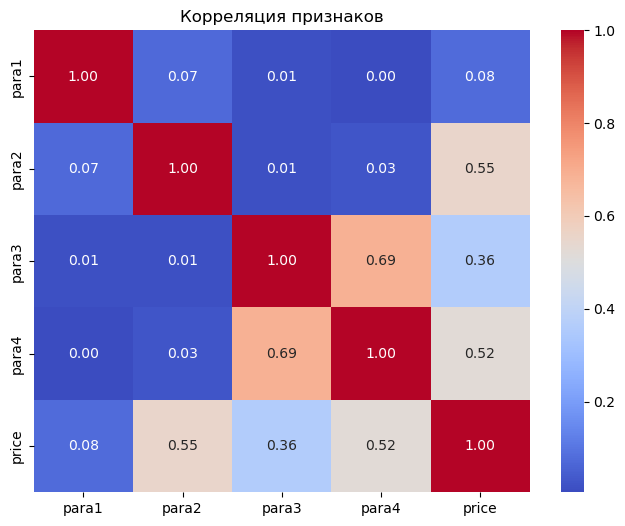

In [63]:
# Визуализация корреляционной матрицы
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляция признаков')
plt.show()

In [ ]:
# Корреляционный анализ показал, что:
наиболее информативными признаками являются para2 и para4;
para1 практически не влияет на цену;
между para3 и para4 существует заметная взаимосвязь.

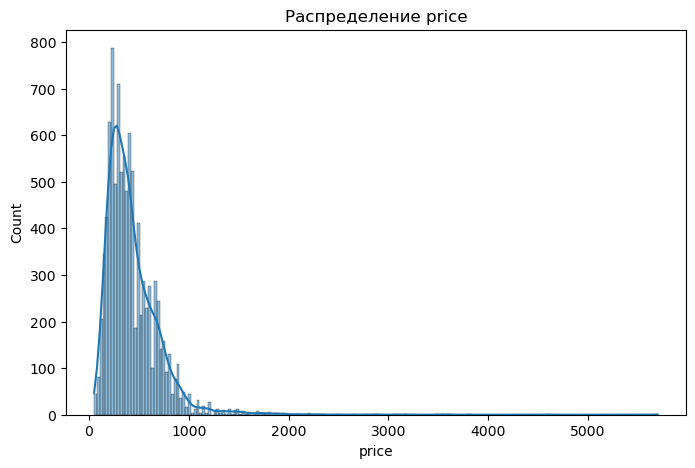

In [64]:
# Распределение цены
plt.figure(figsize=(8,5))

sns.histplot(df['price'], kde=True)

plt.title('Распределение price')
plt.show()

In [ ]:
# Несмотря на выраженную асимметрию распределения price, логарифмическое преобразование не применялось, 
# так как используемая модель Random Forest устойчива к подобным распределениям данных.

In [65]:
# Разделение признаков и target
X = df.drop('price', axis=1)
y = df['price']

In [66]:
# Разделение данных на тренировочный и тестовый наборы данных
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [67]:
# Создание модели
model = RandomForestRegressor(n_estimators=200, random_state=42)
# Обучение модели
model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [68]:
# Предсказания на тестовой выборке
y_pred = model.predict(X_test)

In [69]:
# Оценка качества модели
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print('MAE:', mae)
print('RMSE:', rmse)
print('R2 Score:', r2)

MAE: 99.1196221841205
RMSE: 172.36036633920665
R2 Score: 0.6722652425156643


In [ ]:
# Значение MAE показывает, что в среднем модель ошибается примерно на 99 единиц цены. Это говорит о достаточно хорошем качестве 
предсказаний для базовой модели.
Метрика RMSE выше значения MAE, что указывает на наличие отдельных предсказаний с более крупной ошибкой. Вероятно, в данных присутствуют 
выбросы или объекты с очень высокой ценой, которые модель предсказывает менее точно.
Коэффициент детерминации R2 = 0.67 означает, что модель объясняет около 67% зависимости цены от признаков. Это можно считать хорошим результатом
для данной модели машинного обучения.

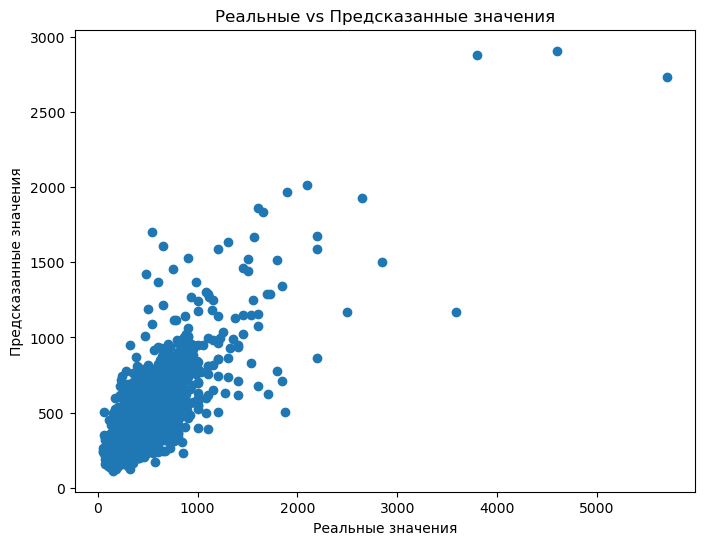

In [71]:
# Визуализация точности модели, cравнение реальных и предсказанных значений

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel('Реальные значения')
plt.ylabel('Предсказанные значения')
plt.title('Реальные vs Предсказанные значения')

plt.show()

In [ ]:
# На графике сравнения реальных и предсказанных значений видно, что модель в целом улавливает зависимость между признаками и ценой. Большинство точек 
располагается по направлению диагонали, что говорит о наличии связи между реальными и предсказанными значениями.
Однако заметно, что при больших значениях цены разброс точек увеличивается. Это означает, что модель хуже предсказывает дорогие объекты и допускает
более высокую ошибку на экстремальных значениях.
Несмотря на это, модель показывает удовлетворительное качество и может использоваться для базового прогнозирования цен.

In [72]:
# Решила улучшить метрики модели за счет тюнинга гиперпараметров
from sklearn.model_selection import GridSearchCV

In [73]:
# Создание модели
rf = RandomForestRegressor(random_state=42)

In [77]:
# Сетка параметров
param_grid = {'n_estimators': [100, 200],'max_depth': [5, 10, 15, None],'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4]}  

In [78]:
# Поиск лучших параметров
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1)

In [79]:
# Обучение
grid_search.fit(X_train, y_train)

,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [80]:
# Лучшие параметры
print(grid_search.best_params_)

{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}


In [81]:
# Лучшая модель
best_rf = grid_search.best_estimator_

In [82]:
# Предсказания
y_pred = best_rf.predict(X_test)

In [83]:
# Оценка качества модели
mae1 = mean_absolute_error(y_test, y_pred)
rmse1 = np.sqrt(mean_squared_error(y_test, y_pred))
r2_1 = r2_score(y_test, y_pred)

print(f'MAE: {mae1}')
print(f'RMSE: {rmse1}')
print(f'R2 Score: {r2_1}')

MAE: 94.81420414760001
RMSE: 169.3026398997589
R2 Score: 0.6837903310897749


In [84]:
# Получаем важность признаков
importance = model.feature_importances_

# Создаем DataFrame
feature_importance = pd.DataFrame({'Признак': X.columns, 'Важность': importance})

# Сортируем по убыванию
feature_importance = feature_importance.sort_values(by='Важность', ascending=False)

# Выводим таблицу
print(feature_importance)

  Признак  Важность
1   para2  0.505819
3   para4  0.326822
2   para3  0.119289
0   para1  0.048070


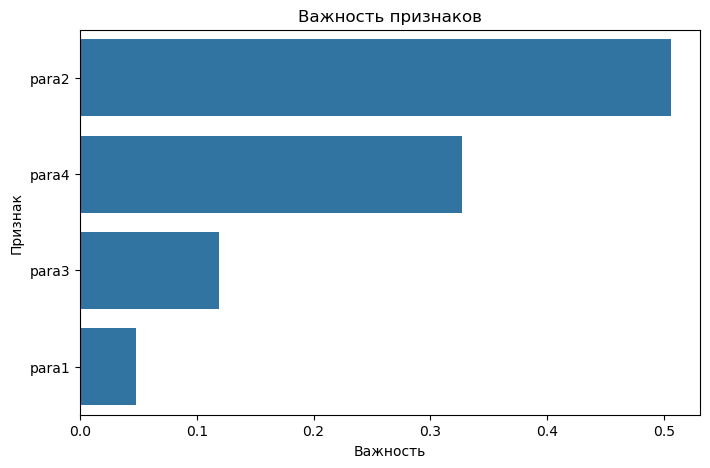

In [85]:
# График важности признаков
plt.figure(figsize=(8, 5))

sns.barplot(x='Важность', y='Признак',  data=feature_importance)
plt.title('Важность признаков')
plt.show()

In [43]:
# Наиболее важные признаки (2 и 4) сильнее всего влияют на прогноз цены.

In [ ]:
# Вывод после подбора гиперпараметров
После подбора гиперпараметров качество модели немного улучшилось:
MAE уменьшилась с 99.12 до 94.81;
RMSE уменьшилась с 172.36 до 169.30;
R2 Score увеличился с 0.67 до 0.68.
Это показывает, что оптимизация параметров позволила модели делать более точные предсказания и немного лучше объяснять зависимость цены от признаков.
Несмотря на улучшение, изменения оказались не очень большими. Это может говорить о том, что качество модели ограничено не только настройками
алгоритма, но и самим набором данных:
признаков может быть недостаточно для точного прогнозирования;
в данных могут присутствовать выбросы;
часть зависимостей может быть слишком сложной или случайной.
По графику реальных и предсказанных значений видно, что модель хорошо определяет общий тренд, однако ошибки увеличиваются при высоких значениях цены.
Это означает, что модель хуже прогнозирует дорогие объекты.
В целом модель показывает стабильный и достаточно хороший результат для задачи регрессии. Дополнительное улучшение качества возможно при: 
добавлении новых признаков, обработке выбросов, увеличении объема данных, использовании более сложных ансамблевых моделей.

In [ ]:
# В ходе работы в отдельных файлах были протестированы несколько моделей машинного обучения:
Linear Regression;
Random Forest Regressor;
XGBoost Regressor;
LightGBM Regressor;
GradientBoostingRegressor.
Лучшие результаты показала модель Random Forest Regressor после подбора гиперпараметров (схожие результаты показала модель GradientBoostingRegressor):
MAE = 94.81
RMSE = 169.30
R2 Score = 0.68
Модель Linear Regression показала наиболее низкое качество, так как она способна описывать только линейные зависимости между признаками и целевой
переменной. Модели XGBoost и LightGBM также показали хорошие результаты, однако не смогли превзойти Random Forest.
Причины, по которым Random Forest оказался лучше:
модель хорошо работает на небольших и средних табличных датасетах;
Random Forest устойчив к переобучению;
алгоритм эффективно обрабатывает нелинейные зависимости;
модель менее чувствительна к шуму и выбросам;
при небольшом количестве признаков Random Forest часто показывает более стабильный результат, чем бустинговые модели.

Также можно предположить, что набор данных содержит ограниченное количество информации для более сложных алгоритмов. Поэтому дополнительные 
возможности XGBoost и LightGBM не дали существенного прироста качества.
Таким образом, Random Forest Regressor оказался наиболее подходящей моделью для данной задачи, обеспечив лучшее соотношение точности, устойчивости 
и качества прогнозирования среди всех протестированных алгоритмов.